![Two data scientists working on a dashboard.](hr-image-small.png)

A common problem when creating models to generate business value from data is that the datasets can be so large that it can take days for the model to generate predictions. Ensuring that your dataset is stored as efficiently as possible is crucial for allowing these models to run on a more reasonable timescale without having to reduce the size of the dataset.

You've been hired by a major online data science training provider called *Training Data Ltd.* to clean up one of their largest customer datasets. This dataset will eventually be used to predict whether their students are looking for a new job or not, information that they will then use to direct them to prospective recruiters.

You've been given access to `customer_train.csv`, which is a subset of their entire customer dataset, so you can create a proof-of-concept of a much more efficient storage solution. The dataset contains anonymized student information, and whether they were looking for a new job or not during training:

| Column                   | Description                                                                      |
|------------------------- |--------------------------------------------------------------------------------- |
| `student_id`             | A unique ID for each student.                                                    |
| `city`                   | A code for the city the student lives in.                                        |
| `city_development_index` | A scaled development index for the city.                                         |
| `gender`                 | The student's gender.                                                            |
| `relevant_experience`    | An indicator of the student's work relevant experience.                          |
| `enrolled_university`    | The type of university course enrolled in (if any).                              |
| `education_level`        | The student's education level.                                                   |
| `major_discipline`       | The educational discipline of the student.                                       |
| `experience`             | The student's total work experience (in years).                                  |
| `company_size`           | The number of employees at the student's current employer.                       |
| `company_type`           | The type of company employing the student.                                       |
| `last_new_job`           | The number of years between the student's current and previous jobs.             |
| `training_hours`         | The number of hours of training completed.                                       |
| `job_change`             | An indicator of whether the student is looking for a new job (`1`) or not (`0`). |

In [2]:
# Import necessary libraries
import pandas as pd

# Load the dataset
ds_jobs = pd.read_csv("customer_train.csv")

# View the dataset
ds_jobs.head()

,student_id,city,city_development_index,gender,relevant_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,job_change
0,8949,city_103,0.920,Male,Has relevant experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevant experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevant experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevant experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevant experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [3]:
# Create a copy of ds_jobs for transforming
ds_jobs_transformed = ds_jobs.copy()

# Start coding here. Use as many cells as you like!

In [4]:
ds_jobs_transformed.dtypes

student_id                  int64
city                       object
city_development_index    float64
gender                     object
relevant_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
job_change                float64
dtype: object

In [5]:
empty_list = []
for col in ds_jobs_transformed.columns:
    if ds_jobs_transformed[col].dtype == 'object':
        empty_list.append({col: ds_jobs_transformed[col].nunique()})

In [6]:
empty_list



[{'city': 123},
 {'gender': 3},
 {'relevant_experience': 2},
 {'enrolled_university': 3},
 {'education_level': 5},
 {'major_discipline': 6},
 {'experience': 22},
 {'company_size': 8},
 {'company_type': 6},
 {'last_new_job': 6}]

In [7]:
ds_jobs_transformed['gender'].value_counts()

gender
Male      13221
Female     1238
Other       191
Name: count, dtype: int64

In [8]:
for entry in empty_list:
    for col, nuniques in entry.items():
        if nuniques == 2:
            uniques = list(ds_jobs_transformed[col].dropna().unique())
            mapping = {uniques[0]: 0, uniques[1]: 1}
            ds_jobs_transformed[col] = ds_jobs_transformed[col].map(mapping).astype('bool')

In [9]:
ds_jobs_transformed.dtypes

student_id                  int64
city                       object
city_development_index    float64
gender                     object
relevant_experience          bool
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
job_change                float64
dtype: object

In [56]:
ds_jobs_transformed['job_change'] = ds_jobs_transformed['job_change'].astype('bool')

In [11]:
for col in ds_jobs_transformed.columns:        # loop over every column name
    if 'int' in str(ds_jobs_transformed[col].dtype):   # check if it's an integer type
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('int32')  # convert it


In [12]:
ds_jobs_transformed.dtypes

student_id                  int32
city                       object
city_development_index    float64
gender                     object
relevant_experience          bool
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int32
job_change                float64
dtype: object

In [13]:
for col in ds_jobs_transformed.columns:        # loop over every column name
    if 'float' in str(ds_jobs_transformed[col].dtype):   # check if it's a float type
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('float16')  # convert it

In [14]:
ds_jobs_transformed.dtypes

student_id                  int32
city                       object
city_development_index    float16
gender                     object
relevant_experience          bool
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int32
job_change                float16
dtype: object

In [17]:
for col in ds_jobs_transformed.columns:        # loop over every column name
    if 'object' in str(ds_jobs_transformed[col].dtype):   # check if it's an object type
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('category')  # convert it
        print(ds_jobs_transformed[col].value_counts())

city
city_103    4355
city_21     2702
city_16     1533
city_114    1336
city_160     845
            ... 
city_111       3
city_121       3
city_129       3
city_171       1
city_140       1
Name: count, Length: 123, dtype: int64
gender
Male      13221
Female     1238
Other       191
Name: count, dtype: int64
enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64
education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64
major_discipline
STEM               14492
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64
experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12    

In [59]:
education_category = ['no_enrollment', 'part_time_course','full_time_course']
ds_jobs_transformed["enrolled_university"] = pd.Categorical(
    ds_jobs_transformed["enrolled_university"],
    categories=education_category,
    ordered=True
)

In [61]:
education_level_category = ['Primary School','High School', 'Graduate', 'Masters' , 'Phd' ]
ds_jobs_transformed["education_level"] = pd.Categorical(
    ds_jobs_transformed["education_level"],
    categories=education_category,
    ordered=True
)

In [62]:
company_size_category = ['<10','10-49', '50-99', '100-499' , '500-999' , '1000-4999' , '5000-9999' , '10000+' ]
ds_jobs_transformed["company_size"] = pd.Categorical(
    ds_jobs_transformed["company_size"],
    categories=company_size_category,
    ordered=True
)

In [64]:
last_job_category = ['never','1' , '2', '3', '>4' ]
ds_jobs_transformed["last_new_job"] = pd.Categorical(
    ds_jobs_transformed["last_new_job"],
    categories=last_job_category,
    ordered=True
)

In [18]:
ds_jobs_transformed.dtypes

student_id                   int32
city                      category
city_development_index     float16
gender                    category
relevant_experience           bool
enrolled_university       category
education_level           category
major_discipline          category
experience                category
company_size              category
company_type              category
last_new_job              category
training_hours               int32
job_change                 float16
dtype: object

In [69]:
category_value = [i for i in range(0, 21)]

In [70]:
for i in range(len(category_value)):
    category_value[i] = str(category_value[i])

In [74]:
category_value

['<1',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '>20']

In [72]:
category_value[category_value.index('0')] = '<1'

In [73]:
category_value.append('>20')

In [40]:
ds_jobs_transformed["experience"] = pd.Categorical(
    ds_jobs_transformed["experience"],
    categories=category_value,
    ordered=True
)

In [51]:
ds_jobs_transformed = ds_jobs_transformed[
    (ds_jobs_transformed["experience"] >= '10') &
    (ds_jobs_transformed["company_size"].isin(['10000+', '1000-4999', '5000-9999']))
]

In [52]:
ds_jobs_transformed

/Users/auroraxiao/Desktop/Data Science Project/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,student_id,city,city_development_index,gender,relevant_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,job_change
9,699,city_103,0.919922,NaN,False,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0
12,25619,city_61,0.913086,Male,False,no_enrollment,Graduate,STEM,>20,1000-4999,Pvt Ltd,3,23,0.0
31,22293,city_103,0.919922,Male,False,Part time course,Graduate,STEM,19,5000-9999,Pvt Ltd,>4,141,0.0
34,26494,city_16,0.910156,Male,False,no_enrollment,Graduate,Business Degree,12,5000-9999,Pvt Ltd,3,145,0.0
40,2547,city_114,0.925781,Female,False,Full time course,Masters,STEM,16,1000-4999,Public Sector,2,14,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19097,25447,city_103,0.919922,Male,False,no_enrollment,Graduate,STEM,>20,1000-4999,Pvt Ltd,>4,57,0.0
19101,6803,city_16,0.910156,Male,False,no_enrollment,High School,NaN,10,10000+,Pvt Ltd,1,89,0.0
19103,32932,city_10,0.895020,Male,False,Part time course,Masters,Other,>20,1000-4999,Pvt Ltd,>4,18,0.0
19128,3365,city_16,0.910156,NaN,False,no_enrollment,Graduate,Humanities,>20,1000-4999,Pvt Ltd,>4,23,0.0


In [53]:
ds_jobs_transformed.memory_usage()

Index                     17216
student_id                 8608
city                       7304
city_development_index     4304
gender                     2284
relevant_experience        2152
enrolled_university        2284
education_level            2364
major_discipline           2372
experience                 2876
company_size               2516
company_type               2372
last_new_job               2372
training_hours             8608
job_change                 4304
dtype: int64

In [55]:
ds_jobs.memory_usage()

Index                        132
student_id                153264
city                      153264
city_development_index    153264
gender                    153264
relevant_experience       153264
enrolled_university       153264
education_level           153264
major_discipline          153264
experience                153264
company_size              153264
company_type              153264
last_new_job              153264
training_hours            153264
job_change                153264
dtype: int64

In [66]:
ds_jobs_transformed.shape


(2152, 14)

## Solution

In [ ]:
# Import necessary libraries
import pandas as pd

# Load the dataset and create a copy
ds_jobs = pd.read_csv("customer_train.csv")
ds_jobs_transformed = ds_jobs.copy()

# EDA to help identify ordinal, nominal, and two-factor categories
for col in ds_jobs.select_dtypes("object").columns:
    print(ds_jobs_transformed[col].value_counts(), '\n')

# Create a dictionary of columns containing ordered categorical data
ordered_cats = {
    'enrolled_university': ['no_enrollment', 'Part time course', 'Full time course'],
    'education_level': ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd'],
    'experience': ['<1'] + list(map(str, range(1, 21))) + ['>20'],
    'company_size': ['<10', '10-49', '50-99', '100-499', '500-999', '1000-4999', '5000-9999', '10000+'],
    'last_new_job': ['never', '1', '2', '3', '4', '>4']
}

# Create a mapping dictionary of columns containing two-factor categories to convert to Booleans
two_factor_cats = {
    'relevant_experience': {'No relevant experience': False, 'Has relevant experience': True},
    'job_change': {0.0: False, 1.0: True}
}

# Loop through DataFrame columns to efficiently change data types
for col in ds_jobs_transformed:
    
    # Convert two-factor categories to bool
    if col in ['relevant_experience', 'job_change']:
        ds_jobs_transformed[col] = ds_jobs_transformed[col].map(two_factor_cats[col])
    
    # Convert integer columns to int32
    elif col in ['student_id', 'training_hours']:
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('int32')
    
    # Convert float columns to float16
    elif col == 'city_development_index':
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('float16')
    
    # Convert columns containing ordered categorical data to ordered categories using dict
    elif col in ordered_cats.keys():
        category = pd.CategoricalDtype(ordered_cats[col], ordered=True)
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype(category)
    
    # Convert remaining columns to standard categories
    else:
        ds_jobs_transformed[col] = ds_jobs_transformed[col].astype('category')
        
# Filter students with 10 or more years experience at companies with at least 1000 employees
ds_jobs_transformed = ds_jobs_transformed[(ds_jobs_transformed['experience'] >= '10') & (ds_jobs_transformed['company_size'] >= '1000-4999')]

In [3]:
def store_lower(_dict, _string):
  """Add a mapping between `_string` and a lowercased version of `_string` to `_dict`

  Args:
    _dict (dict): The dictionary to update.
    _string (str): The string to add.
  """
  orig_string = _string
  _string = _string.lower()
  _dict[orig_string] = _string
  print(orig_string, _string)

d = {}
s = 'Hello'

store_lower(d, s)

Hello hello


In [2]:
print(d, s)

{'Hello': 'hello'} Hello


In [5]:
import random
import time

class stock:
    def __init__(self, ticker):
        self.ticker = ticker

    def __enter__(self):
        print(f'Opening stock ticker for {self.ticker}')
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        print(f'Closing stock ticker for {self.ticker}')

    def price(self):
        # Simulate a fluctuating price
        return random.uniform(100, 200)
        

In [7]:
with stock('NVDA') as nvda:
    print(nvda.price())

Opening stock ticker for NVDA
123.86040519188215
Closing stock ticker for NVDA


In [8]:
pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 26.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [yfinance]/18 [yfinance]]oup4]zer]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
import yfinance as yf

nvda = yf.Ticker('NVDA')
price = nvda.history(period='5d')['Close']
print(price)

Date
2026-06-26 00:00:00-04:00    192.529999
2026-06-29 00:00:00-04:00    194.970001
2026-06-30 00:00:00-04:00    200.089996
2026-07-01 00:00:00-04:00    197.580002
2026-07-02 00:00:00-04:00    194.830002
Name: Close, dtype: float64


In [16]:
x = 50

def one():
  x = 10

def two():
  global x
  print(x)
  x = 30

def three():
  x = 100
  print(x)

for func in [one, two, three]:
  func()
  print(x)

50
50
30
100
30


In [1]:
### test on the DiD
import numpy as np
import pandas as pd
n = 100   # users per week per group
 
rows = []
 
# --- PRE-PERIOD: weeks 1–4 ---
# Both groups rise at same rate (~1pp/week) — parallel trends holds
for week in [1, 2, 3, 4]:
    # US (treat): starts at 58%, rises 1pp/week
    treat_outcomes = 0.58 + 0.01 * week + np.random.normal(0, 0.04, n)
    for o in treat_outcomes:
        rows.append({'week': week, 'group': 'treat (US)',
                     'period': 'pre', 'outcome': np.clip(o, 0, 1)})
 
    # Brazil (control): starts at 44%, rises 1pp/week (same slope)
    control_outcomes = 0.44 + 0.01 * week + np.random.normal(0, 0.04, n)
    for o in control_outcomes:
        rows.append({'week': week, 'group': 'control (Brazil)',
                     'period': 'pre', 'outcome': np.clip(o, 0, 1)})
 
# --- POST-PERIOD: weeks 5–7 ---
# Tutorial rolls out at week 5 in US only
# US gets extra +8pp boost on top of natural trend
# Brazil continues same natural trend
for week in [5, 6, 7]:
    # US (treat): continues trend + tutorial boost
    treat_outcomes = 0.58 + 0.01 * week + 0.08 + np.random.normal(0, 0.04, n)
    for o in treat_outcomes:
        rows.append({'week': week, 'group': 'treat (US)',
                     'period': 'post', 'outcome': np.clip(o, 0, 1)})
 
    # Brazil (control): just continues natural trend
    control_outcomes = 0.44 + 0.01 * week + np.random.normal(0, 0.04, n)
    for o in control_outcomes:
        rows.append({'week': week, 'group': 'control (Brazil)',
                     'period': 'post', 'outcome': np.clip(o, 0, 1)})
 
df = pd.DataFrame(rows)
treatment_week = 5   # tutorial rolled out at week 5

In [2]:
df

,week,group,period,outcome
0,1,treat (US),pre,0.542276
1,1,treat (US),pre,0.566530
2,1,treat (US),pre,0.579229
3,1,treat (US),pre,0.587566
4,1,treat (US),pre,0.617491
...,...,...,...,...
1395,7,control (Brazil),post,0.499680
1396,7,control (Brazil),post,0.600028
1397,7,control (Brazil),post,0.467963
1398,7,control (Brazil),post,0.525502


In [3]:
pre_data = df[df['period'] == 'pre']

In [5]:
pre_data.groupby(['week','group'])['outcome'].mean().unstack()

group,control (Brazil),treat (US)
week,,
1,0.455254,0.594574
2,0.456920,0.601605
3,0.474244,0.605125
4,0.480678,0.619503


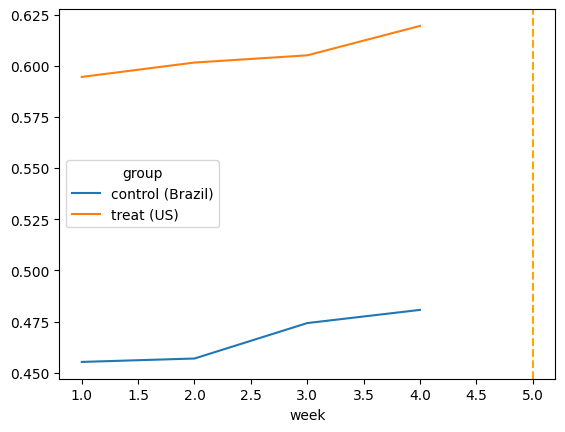

In [8]:
import matplotlib.pyplot as plt
pre_data.groupby(['week','group'])['outcome'].mean().unstack().plot()
plt.axvline(x=treatment_week, color='orange', linestyle='--', label='rollout')

In [ ]:

WITH joing_tables AS(

    select distinct accounts.id,
    login_date,
    name,
    from Accounts 
    left join logins on Accounts.id = logins.id),

PREVIOUS_FIVE_DAYS AS(

    select distinct id,
    login_date,
    name,
    lag(login_date, 1) over (partition by id order by login_date) as prev_1,
    lag(login_date, 2) over (partition by id order by login_date) as prev_2,
    lag(login_date, 3) over (partition by id order by login_date) as prev_3,
    lag(login_date, 4) over (partition by id order by login_date) as prev_4
    from joing_table)

select id , name

from PREVIOUS_FIVE_DAYS
where prev_1 is not null and prev_2 is not null and prev_3 is not null and prev_4 is not null and (prev_1 + 1 day interval = login_date and prev_2 + 2 day interval = login_date and prev_3 + 3 day interval = login_date and prev_4 + 4 day interval = login_date)